# Taller 03 — Coloreado de grafos con BT-FC-DO

Implementación de un algoritmo de **Backtracking + Forward Checking + Dynamic Ordering** (BT-FC-DO) para Problemas de Satisfacción de Restricciones (CSP), aplicado al **coloreado de grafos**.

- El grafo se define con una **matriz de adyacencias** simétrica $N \times N$ ($N < 21$): `1` = arista, `0` = sin arista.
- La matriz se puede **leer de un `.txt`** o **generar aleatoriamente**.
- El resultado es una **figura** con el grafo y los nodos coloreados.

**Heurísticas usadas**
- **FC**: al asignar un color, se elimina de los dominios de los vecinos no asignados.
- **DO (variables)**: MRV (mínimo de valores restantes) + desempate por grado (más restricciones).
- **DO (valores)**: LCV (valor que menos restringe a los vecinos).

In [1]:
try:
    import math
    import random
    import copy
    from pathlib import Path

    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.colors import to_hex
except ImportError:
    %pip install matplotlib
    import math
    import random
    import copy
    from pathlib import Path

    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.colors import to_hex

## Matriz de adyacencias

Formato del archivo `.txt`: $N$ líneas con $N$ enteros `0`/`1` separados por espacios. Debe ser simétrica y con diagonal en `0`.

In [2]:
def validar_matriz(matriz):
    """Verifica N x N, N < 21, simétrica y diagonal en 0."""
    n = len(matriz)
    if n == 0 or n >= 21:
        raise ValueError(f"N debe cumplir 1 <= N < 21; recibido N={n}")
    for i, fila in enumerate(matriz):
        if len(fila) != n:
            raise ValueError("La matriz debe ser cuadrada")
        for j, val in enumerate(fila):
            if val not in (0, 1):
                raise ValueError("Solo se permiten valores 0 o 1")
            if i == j and val != 0:
                raise ValueError("La diagonal debe ser 0 (sin bucles)")
            if matriz[i][j] != matriz[j][i]:
                raise ValueError("La matriz debe ser simétrica")
    return n


def leer_matriz(ruta):
    """Lee una matriz de adyacencias desde un archivo .txt."""
    matriz = []
    with open(ruta, encoding="utf-8") as f:
        for linea in f:
            linea = linea.strip()
            if not linea or linea.startswith("#"):
                continue
            fila = [int(x) for x in linea.replace(",", " ").split()]
            matriz.append(fila)
    validar_matriz(matriz)
    return matriz


def generar_matriz_aleatoria(n, p=0.4, semilla=None):
    """Genera una matriz simétrica NxN (N < 21) con probabilidad p de arista."""
    if not (1 <= n < 21):
        raise ValueError("N debe cumplir 1 <= N < 21")
    if semilla is not None:
        random.seed(semilla)

    matriz = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < p:
                matriz[i][j] = matriz[j][i] = 1
    validar_matriz(matriz)
    return matriz


def imprimir_matriz(matriz):
    for fila in matriz:
        print(" ".join(str(x) for x in fila))

## Algoritmo BT-FC-DO

Cada nodo es una variable; el dominio son los colores $\{0, 1, \ldots, k-1\}$.  
La restricción binaria: nodos adyacentes no pueden compartir color.

In [3]:
def grado(matriz, v, candidatos=None):
    """Cantidad de vecinos de v (opcionalmente solo entre 'candidatos')."""
    n = len(matriz)
    if candidatos is None:
        return sum(matriz[v][u] for u in range(n))
    return sum(matriz[v][u] for u in candidatos if u != v)


def seleccionar_variable(asignacion, dominios, matriz):
    """Orden dinámico de variables: MRV + desempate por mayor grado."""
    libres = [v for v in range(len(matriz)) if v not in asignacion]
    return min(
        libres,
        key=lambda v: (len(dominios[v]), -grado(matriz, v, libres)),
    )


def ordenar_valores(var, asignacion, dominios, matriz):
    """Orden dinámico de valores: LCV (menos restrictivo primero)."""

    def restringe(color):
        return sum(
            1
            for u in range(len(matriz))
            if matriz[var][u] and u not in asignacion and color in dominios[u]
        )

    return sorted(dominios[var], key=restringe)


def forward_check(var, color, asignacion, dominios, matriz):
    """Elimina 'color' de los dominios de vecinos no asignados.

    Devuelve (ok, podas) donde podas permite restaurar al hacer backtrack.
    """
    podas = []
    for u in range(len(matriz)):
        if matriz[var][u] and u not in asignacion and color in dominios[u]:
            dominios[u].remove(color)
            podas.append((u, color))
            if not dominios[u]:
                return False, podas
    return True, podas


def restaurar(dominios, podas):
    for u, color in podas:
        dominios[u].add(color)


def bt_fc_do(matriz, k_colores):
    """Resuelve coloreado de grafos con BT + FC + DO.

    Retorna dict {nodo: color} o None si no hay solución con k_colores.
    """
    n = validar_matriz(matriz)
    dominios = {v: set(range(k_colores)) for v in range(n)}
    asignacion = {}
    estadisticas = {"nodos_expandidos": 0, "fallos_fc": 0}

    def buscar():
        if len(asignacion) == n:
            return True

        var = seleccionar_variable(asignacion, dominios, matriz)
        for color in ordenar_valores(var, asignacion, dominios, matriz):
            estadisticas["nodos_expandidos"] += 1
            asignacion[var] = color
            ok, podas = forward_check(var, color, asignacion, dominios, matriz)
            if ok and buscar():
                return True
            if not ok:
                estadisticas["fallos_fc"] += 1
            restaurar(dominios, podas)
            del asignacion[var]

        return False

    exito = buscar()
    return (dict(asignacion) if exito else None), estadisticas


def colorear_grafo(matriz, k_colores=None):
    """Colorea el grafo. Si k_colores es None, busca el mínimo k factible."""
    n = validar_matriz(matriz)
    delta = max((grado(matriz, v) for v in range(n)), default=0)
    # Cota superior clásica: Δ + 1 colores bastan
    k_max = delta + 1 if delta > 0 else 1

    if k_colores is not None:
        solucion, stats = bt_fc_do(matriz, k_colores)
        return solucion, k_colores, stats

    for k in range(1, k_max + 1):
        solucion, stats = bt_fc_do(matriz, k)
        if solucion is not None:
            return solucion, k, stats

    return None, k_max, stats

## Visualización

In [4]:
def posiciones_circulares(n):
    """Layout circular para N nodos."""
    return {
        i: (
            math.cos(2 * math.pi * i / n - math.pi / 2),
            math.sin(2 * math.pi * i / n - math.pi / 2),
        )
        for i in range(n)
    }


def paleta_colores(k):
    """Genera k colores bien separados en el espacio HSV."""
    cmap = plt.get_cmap("tab20" if k <= 20 else "hsv")
    if k <= 20:
        return [to_hex(cmap(i % 20)) for i in range(k)]
    return [to_hex(cmap(i / max(k, 1))) for i in range(k)]


def dibujar_grafo_coloreado(matriz, coloreado, titulo="Coloreado BT-FC-DO", figsize=(8, 8)):
    """Dibuja el grafo con nodos coloreados según la asignación CSP."""
    n = len(matriz)
    pos = posiciones_circulares(n)
    k = (max(coloreado.values()) + 1) if coloreado else 0
    colores = paleta_colores(max(k, 1))

    fig, ax = plt.subplots(figsize=figsize)

    # Aristas
    for i in range(n):
        for j in range(i + 1, n):
            if matriz[i][j]:
                x1, y1 = pos[i]
                x2, y2 = pos[j]
                ax.plot([x1, x2], [y1, y2], color="#9aa0a6", linewidth=1.4, zorder=1)

    # Nodos
    for v in range(n):
        x, y = pos[v]
        color = colores[coloreado[v]] if coloreado is not None else "#dddddd"
        ax.scatter([x], [y], s=900, c=color, edgecolors="#222222", linewidths=1.6, zorder=3)
        ax.text(x, y, str(v), ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)

    ax.set_title(titulo, fontsize=13)
    ax.set_aspect("equal")
    ax.axis("off")

    if coloreado is not None and k > 0:
        leyenda = [
            mpatches.Patch(facecolor=colores[c], edgecolor="#222222", label=f"Color {c}")
            for c in range(k)
        ]
        ax.legend(handles=leyenda, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=min(k, 6), frameon=False)

    plt.tight_layout()
    return fig

## Ejemplo 1 — Matriz leída desde archivo

Matriz leída desde grafo_ejemplo.txt (N=5):
0 1 1 0 1
1 0 1 1 0
1 1 0 1 1
0 1 1 0 1
1 0 1 1 0

Solución con 3 colores: {2: 0, 0: 1, 1: 2, 3: 1, 4: 2}
Nodos expandidos: 5 | Fallos FC: 0


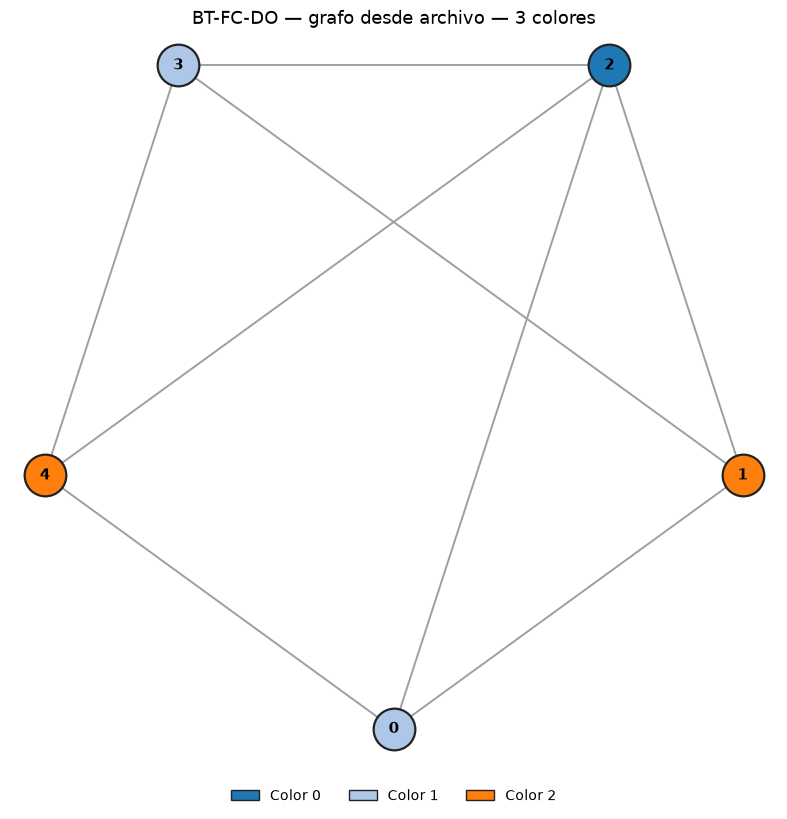

In [5]:
ruta = Path("grafo_ejemplo.txt")
if not ruta.exists():
    # Por si el notebook se ejecuta desde otra carpeta de trabajo
    ruta = Path("taller03") / "grafo_ejemplo.txt"

matriz_archivo = leer_matriz(ruta)
print(f"Matriz leída desde {ruta} (N={len(matriz_archivo)}):")
imprimir_matriz(matriz_archivo)

coloreado, k, stats = colorear_grafo(matriz_archivo)
print(f"\nSolución con {k} colores: {coloreado}")
print(f"Nodos expandidos: {stats['nodos_expandidos']} | Fallos FC: {stats['fallos_fc']}")

fig = dibujar_grafo_coloreado(
    matriz_archivo,
    coloreado,
    titulo=f"BT-FC-DO — grafo desde archivo — {k} colores",
)
plt.show()

## Ejemplo 2 — Matriz generada aleatoriamente

Matriz aleatoria N=12, p=0.35, seed=42:
0 0 1 1 1 0 0 0 1 0 1 1
0 0 0 1 1 0 0 1 0 0 1 0
1 0 0 0 1 1 0 1 1 1 0 0
1 1 0 0 0 0 0 0 0 0 0 0
1 1 1 0 0 0 0 0 1 1 1 1
0 0 1 0 0 0 1 1 1 0 0 0
0 0 0 0 0 1 0 1 1 0 0 0
0 1 1 0 0 1 1 0 1 0 1 0
1 0 1 0 1 1 1 1 0 0 0 0
0 0 1 0 1 0 0 0 0 0 0 0
1 1 0 0 1 0 0 1 0 0 0 0
1 0 0 0 1 0 0 0 0 0 0 0

Solución con 4 colores: {4: 0, 0: 1, 2: 2, 8: 3, 7: 0, 5: 1, 6: 2, 10: 2, 1: 1, 9: 1, 11: 2, 3: 0}
Nodos expandidos: 12 | Fallos FC: 0


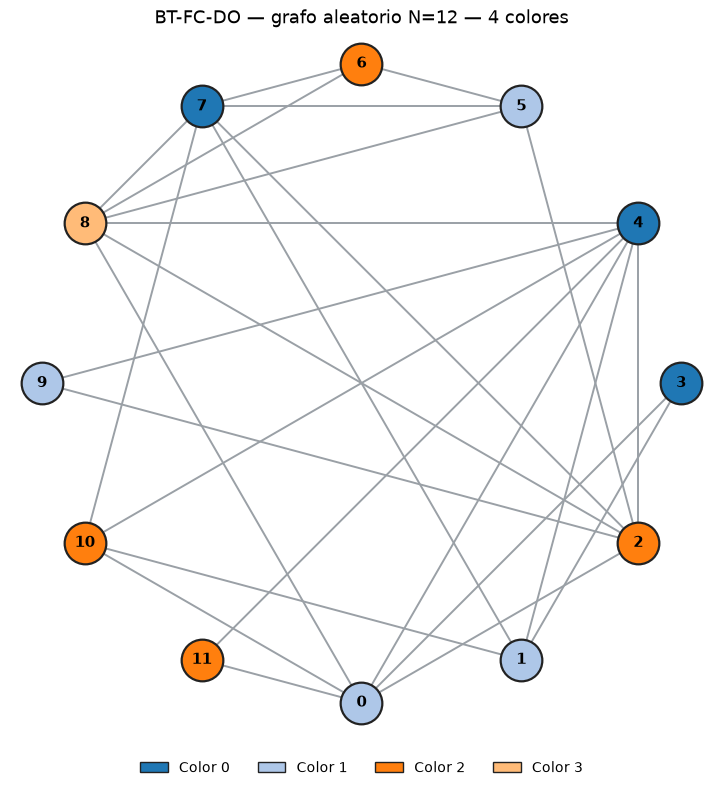

In [6]:
N = 12
P_ARISTA = 0.35
SEMILLA = 42

matriz_rand = generar_matriz_aleatoria(N, p=P_ARISTA, semilla=SEMILLA)
print(f"Matriz aleatoria N={N}, p={P_ARISTA}, seed={SEMILLA}:")
imprimir_matriz(matriz_rand)

coloreado_r, k_r, stats_r = colorear_grafo(matriz_rand)
print(f"\nSolución con {k_r} colores: {coloreado_r}")
print(f"Nodos expandidos: {stats_r['nodos_expandidos']} | Fallos FC: {stats_r['fallos_fc']}")

fig = dibujar_grafo_coloreado(
    matriz_rand,
    coloreado_r,
    titulo=f"BT-FC-DO — grafo aleatorio N={N} — {k_r} colores",
)
plt.show()

## Verificación de la solución

In [7]:
def es_coloreado_valido(matriz, coloreado):
    """True si ningún par de vecinos comparte color."""
    if coloreado is None:
        return False
    n = len(matriz)
    for i in range(n):
        for j in range(i + 1, n):
            if matriz[i][j] and coloreado[i] == coloreado[j]:
                return False
    return True


print("Archivo válido?", es_coloreado_valido(matriz_archivo, coloreado))
print("Aleatorio válido?", es_coloreado_valido(matriz_rand, coloreado_r))

Archivo válido? True
Aleatorio válido? True
